# 股票交易策略回测

**策略概要**
- 本金 500 万，固定持有 20 只消费/医药龙头
- 每年 5.1 / 11.1 调仓，权重复平衡至 5%
- 后复权 + 分红入账 + 调仓日再投资

In [1]:
import config as cfg
from data import fetch_daily_quotes, fetch_dividends, fetch_trade_calendar, fetch_benchmark
from backtest import run_backtest
from metrics import compute_metrics, metrics_report, annual_returns
from plot import plot_nav_and_drawdown, plot_annual_returns, plot_holdings_heatmap

print('模块加载完成')

模块加载完成


## Step 1: 获取数据

In [2]:
print('>>> 获取交易日历...')
trade_dates = fetch_trade_calendar(cfg.START_DATE, cfg.END_DATE)

print(f'\n>>> 获取 {len(cfg.STOCK_CODES)} 只股票日线数据（后复权）...')
quotes = fetch_daily_quotes(cfg.STOCK_CODES, cfg.START_DATE, cfg.END_DATE)

print(f'\n>>> 获取分红送配数据...')
dividends = fetch_dividends(cfg.STOCK_CODES)

print(f'\n>>> 获取基准指数 {cfg.BENCHMARK_INDEX} ...')
benchmark_df = fetch_benchmark(cfg.BENCHMARK_INDEX, cfg.START_DATE, cfg.END_DATE)

print('\n=== 数据获取完成 ===')

>>> 获取交易日历...
  ✓ 交易日历获取完成 (1328 个交易日)

>>> 获取 20 只股票日线数据（后复权）...
  ✓ 603288 日线数据获取完成 (1328 条)
  ✓ 600529 日线数据获取完成 (1328 条)
  ✓ 600298 日线数据获取完成 (1328 条)
  ✓ 600329 日线数据获取完成 (1327 条)
  ✓ 600332 日线数据获取完成 (1328 条)
  ✓ 600285 日线数据获取完成 (1328 条)
  ✓ 002507 日线数据获取完成 (1328 条)
  ✓ 600161 日线数据获取完成 (1328 条)
  ✓ 600085 日线数据获取完成 (1328 条)
  ✓ 600887 日线数据获取完成 (1328 条)
  ✓ 000538 日线数据获取完成 (1328 条)
  ✓ 600809 日线数据获取完成 (1328 条)
  ✓ 600305 日线数据获取完成 (1328 条)
  ✓ 601888 日线数据获取完成 (1328 条)
  ✓ 001914 日线数据获取完成 (1328 条)
  ✓ 000423 日线数据获取完成 (1328 条)
  ✓ 600600 日线数据获取完成 (1328 条)
  ✓ 002304 日线数据获取完成 (1328 条)
  ✓ 000568 日线数据获取完成 (1328 条)
  ✓ 000858 日线数据获取完成 (1328 条)

>>> 获取分红送配数据...
  ✓ 603288 分红数据获取完成 (15 条)
  ✓ 600529 分红数据获取完成 (26 条)
  ✓ 600298 分红数据获取完成 (27 条)
  ✓ 600329 分红数据获取完成 (24 条)
  ✓ 600332 分红数据获取完成 (28 条)
  ✓ 600285 分红数据获取完成 (24 条)
  ✓ 002507 分红数据获取完成 (17 条)
  ✓ 600161 分红数据获取完成 (25 条)
  ✓ 600085 分红数据获取完成 (31 条)
  ✓ 600887 分红数据获取完成 (30 条)
  ✓ 000538 分红数据获取完成 (36 条)
  ✓ 600809 分红数据获取完成 (28 条)
  ✓ 600305 分红

## Step 2: 执行回测

In [3]:
daily, trades, holdings = run_backtest(quotes, dividends, trade_dates, benchmark_df)

  调仓日: ['2021-05-06', '2021-11-01', '2022-05-05', '2022-11-01', '2023-05-04', '2023-11-01', '2024-05-06', '2024-11-01', '2025-05-06', '2025-11-03', '2026-05-06']

  回测完成: 1328 个交易日, 114 笔交易


## Step 3: 评价指标

In [4]:
metrics = compute_metrics(daily, trades)
print(metrics_report(metrics))

                     回测评价指标                     

  【收益】
    累计收益率:      -17.07%
    年化收益率:      -3.49%
    超额收益(年化):  -2.43%

  【风险】
    年化波动率:      16.28%
    最大回撤:        -27.82%

  【风险调整收益】
    夏普比率:        -0.26
    卡玛比率:        -0.13

  【基准对比】
    基准年化收益率:  -1.06%
    基准最大回撤:    -45.60%
    基准年化波动率:  18.06%

  【交易】
    总交易成本:      ¥1,722.92
      其中佣金:      ¥791.15
      其中印花税:    ¥852.65
      其中过户费:    ¥79.12
    年化换手率:      29.73%
    总交易笔数:      114
    调仓次数:        11

  【概览】
    最终净值:        ¥4,146,292
    回测年数:        5.3 年



In [5]:
# 逐年收益率
annual_df = annual_returns(daily)
annual_df

,年份,收益率
0,2021,0.128701
1,2022,-0.065800
2,2023,-0.059327
3,2024,0.035071
4,2025,-0.007684
5,2026,-0.180369


## Step 4: 可视化

/tmp/ipykernel_3335/2048576862.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_nav.show()
/tmp/ipykernel_3335/2048576862.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_dd.show()
findfont: Failed to find font weight bold, now using 400.


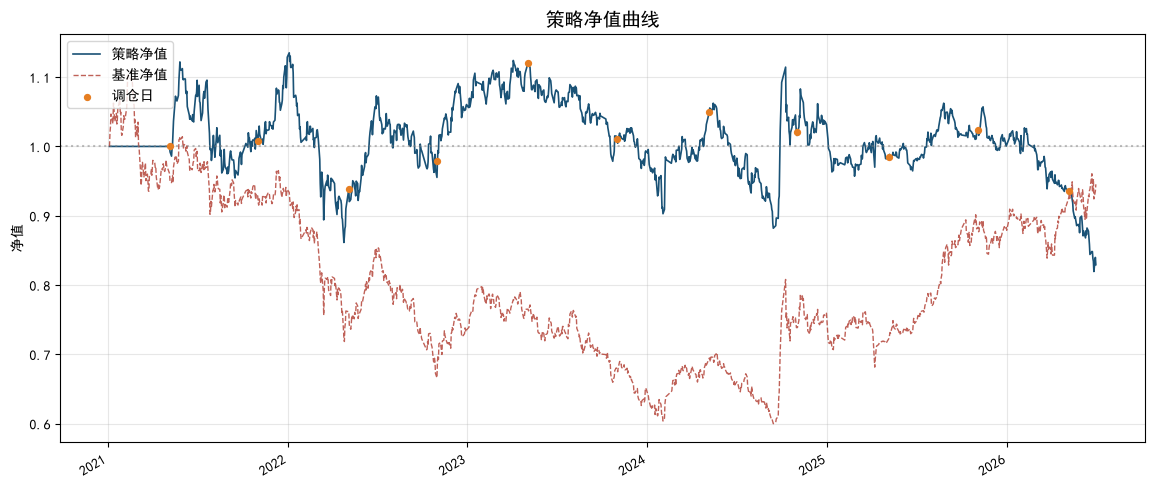

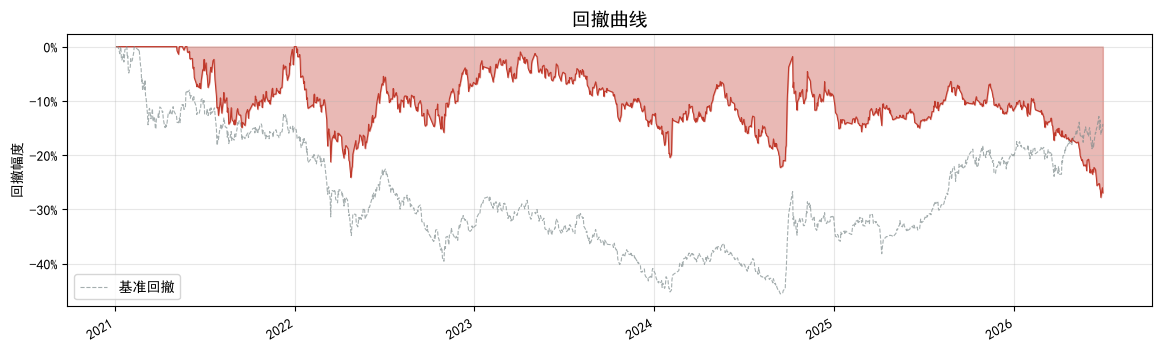

In [6]:
# 净值曲线 + 回撤曲线
fig_nav, fig_dd = plot_nav_and_drawdown(daily, trades)
fig_nav.show()
fig_dd.show()

/tmp/ipykernel_3335/4221436294.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_ar.show()


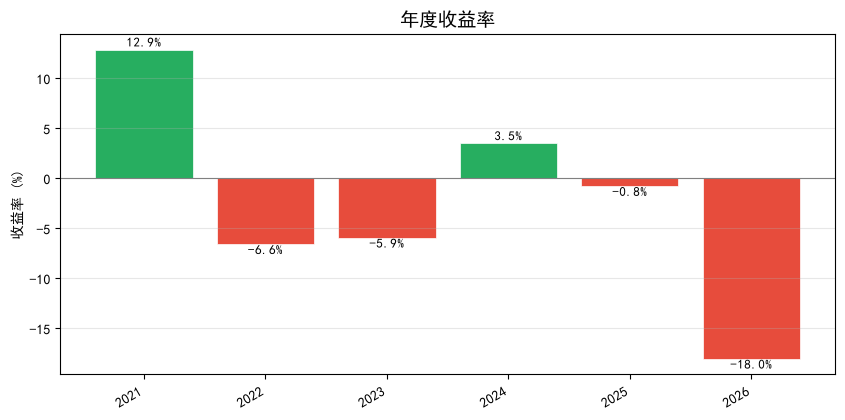

In [7]:
# 年度收益率柱状图
fig_ar = plot_annual_returns(annual_df)
fig_ar.show()

KeyError: 'quarter'

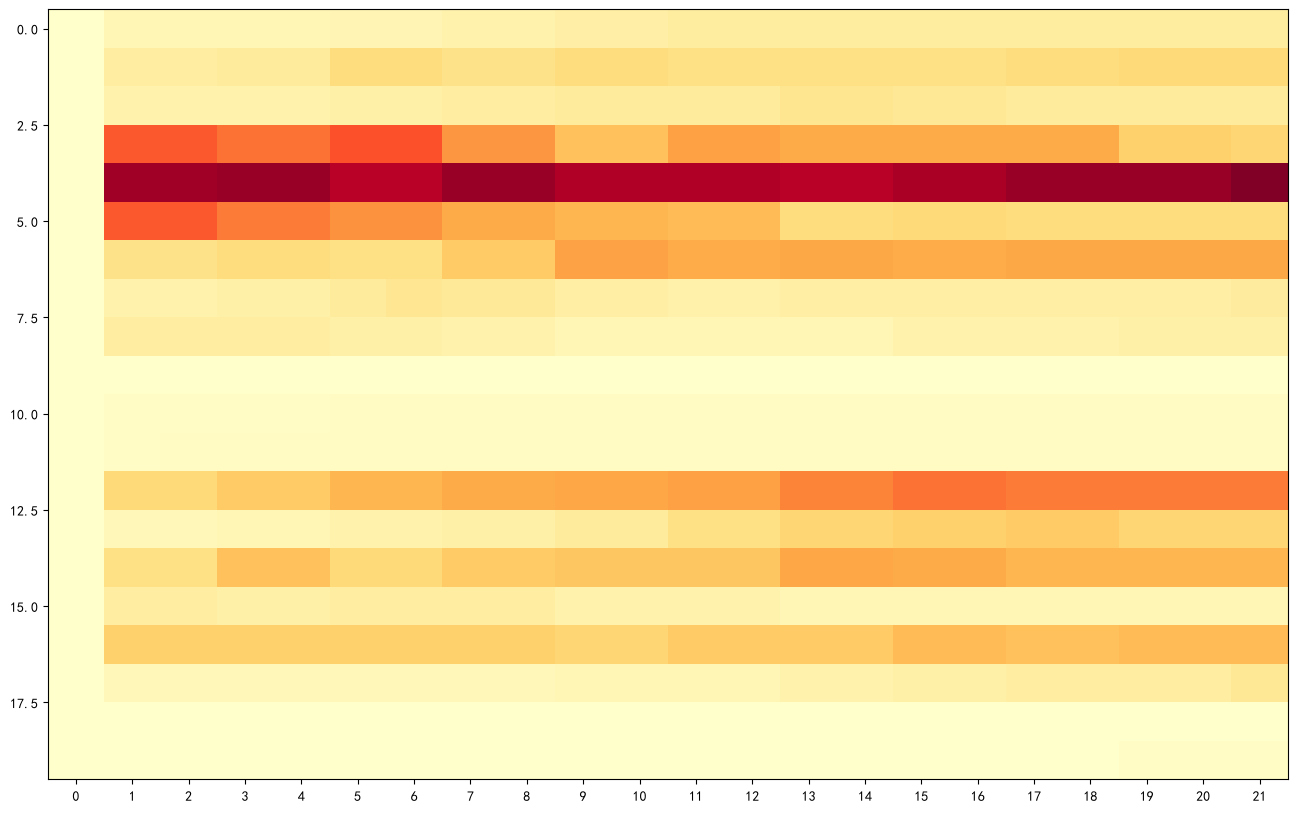

In [8]:
# 持仓热力图
fig_hm = plot_holdings_heatmap(holdings)
fig_hm.show()

## Step 5: 调仓明细

In [9]:
# 按调仓日分组查看交易
from collections import defaultdict
trades_by_date = defaultdict(list)
for t in trades:
    trades_by_date[t.date].append(t)

for d, ts in sorted(trades_by_date.items()):
    buy_count = sum(1 for t in ts if t.action == 'BUY')
    sell_count = sum(1 for t in ts if t.action == 'SELL')
    total_amount = sum(t.amount for t in ts)
    total_cost = sum(t.commission + t.stamp_tax + t.transfer_fee for t in ts)
    reason = ts[0].reason
    print(f'{d}  {reason:12s}  买入 {buy_count:2d} 笔 / 卖出 {sell_count:2d} 笔  '
          f'成交额 ¥{total_amount:>12,.0f}  成本 ¥{total_cost:>8,.2f}')

2021-05-06  建仓            买入 17 笔 / 卖出  0 笔  成交额 ¥   3,928,308  成本 ¥  432.11
2021-11-01  调仓-超配卖出       买入  7 笔 / 卖出  3 笔  成交额 ¥     396,080  成本 ¥   93.53
2022-05-05  调仓-超配卖出       买入  7 笔 / 卖出  5 笔  成交额 ¥     515,013  成本 ¥  156.28
2022-11-01  调仓-超配卖出       买入  7 笔 / 卖出  5 笔  成交额 ¥     531,932  成本 ¥  194.90
2023-05-04  调仓-超配卖出       买入  7 笔 / 卖出  7 笔  成交额 ¥     719,635  成本 ¥  309.25
2023-11-01  调仓-超配卖出       买入  5 笔 / 卖出  4 笔  成交额 ¥     316,758  成本 ¥   86.96
2024-05-06  调仓-超配卖出       买入  6 笔 / 卖出  4 笔  成交额 ¥     514,503  成本 ¥  182.65
2024-11-01  调仓-超配卖出       买入  7 笔 / 卖出  3 笔  成交额 ¥     236,080  成本 ¥   53.12
2025-05-06  调仓-超配卖出       买入  5 笔 / 卖出  5 笔  成交额 ¥     181,160  成本 ¥   67.76
2025-11-03  调仓-超配卖出       买入  4 笔 / 卖出  2 笔  成交额 ¥     467,678  成本 ¥  126.92
2026-05-06  调仓-超配卖出       买入  3 笔 / 卖出  1 笔  成交额 ¥     104,379  成本 ¥   19.46
